# Example of how to use PyBE module

There are 2 parts to this package:
1. A module to evaulate the electric field from a 2D Gaussian charge distribution using the Bassetti Erskine formula (and also for a uniform ellipse)
2. A module to evaluate the electric field inside a beam pipe given using the method of image charges

These 2 modules may be used in tandem with each other

In these examples x, y are arrays of coordinates created using `np.meshgrid` however every function used can be evaluated at a single point or any iterable of points using the same call sequence.

## Imports of plotting function

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm, CenteredNorm

def plot(rho, x, y, Fx, Fy, sampling=6, scale=3):
    # Ensures origin is in the middle and not corner
    x_half = rho.shape[1] / 2
    y_half = rho.shape[0] / 2
    extent = [-x_half, x_half, -y_half, y_half] 
    
    # Plot charge distribution
    fig, ax = plt.subplots(figsize=(12,12))
    ax.imshow(rho, extent=extent, origin='lower', cmap='RdBu_r', norm=CenteredNorm())

    # Plot field lines
    ax.quiver(x[::sampling, ::sampling], 
               y[::sampling, ::sampling],
               Fx[::sampling, ::sampling], 
               Fy[::sampling, ::sampling], 
               scale=scale, pivot='mid')

## Gaussian charge distribution in free space

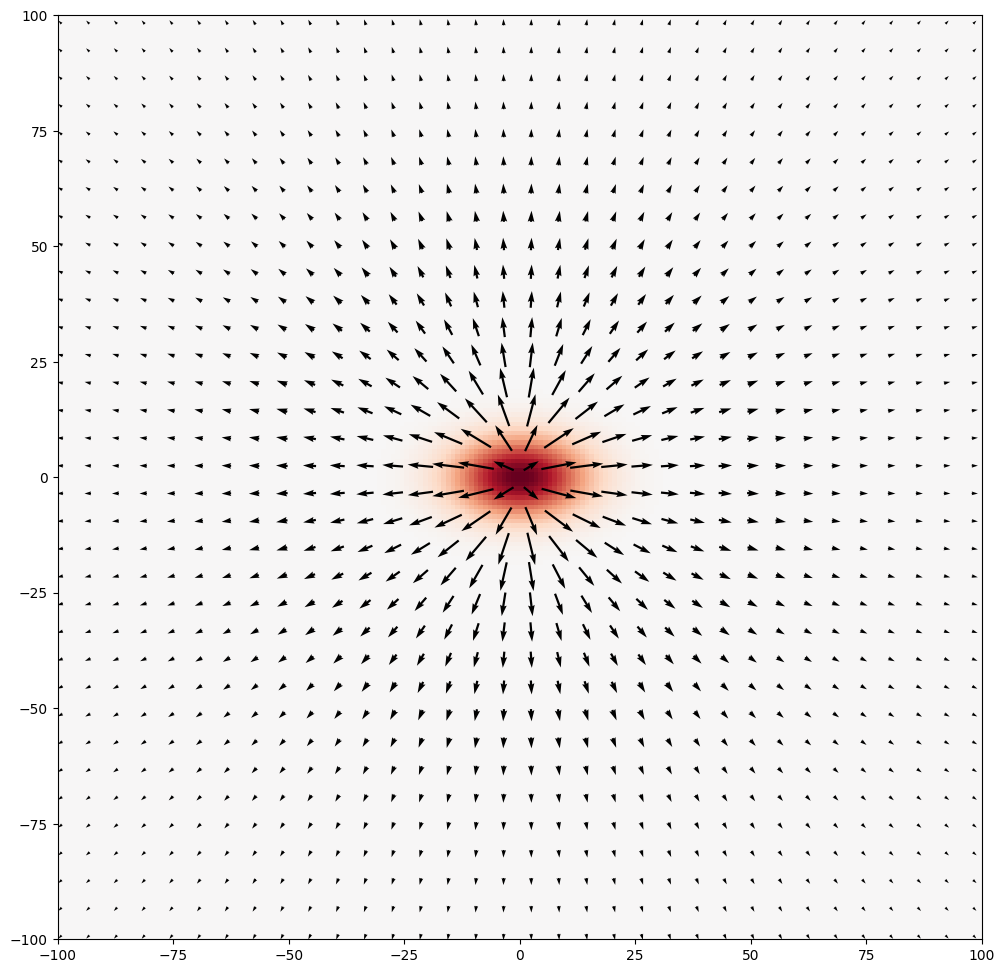

In [ ]:
from bassetti_erskine import gaussian_field

# Set up grid
grid_length = 200
x_list = np.arange(grid_length) + 0.5 - grid_length/2
y_list = np.arange(grid_length) + 0.5 - grid_length/2
x, y = np.meshgrid(x_list, y_list, indexing='ij')

# Choose Gaussian parameters
sigma_x = 6
sigma_y = 10

field_x, field_y = gaussian_field(x, y, sigma_x, sigma_y) # Evaluate field
rho = 1/(2*np.pi*sigma_x*sigma_y)*np.exp(-((x/sigma_x)**2+(y/sigma_y)**2)/2)

plot(rho, x, y, field_x, field_y)


## Uniform elliptical charge distribution in free space

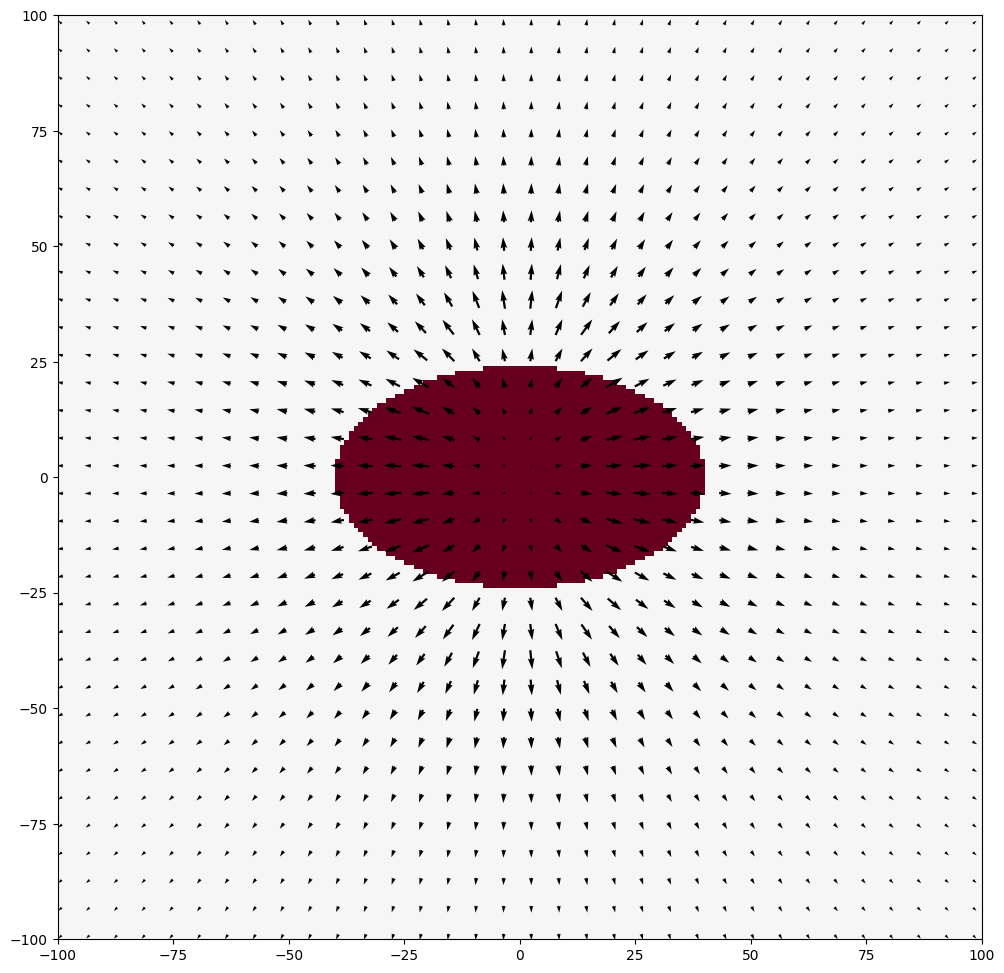

In [ ]:
from bassetti_erskine import uniform_field

# Set up grid
grid_length = 200
x_list = np.arange(grid_length) + 0.5 - grid_length/2
y_list = np.arange(grid_length) + 0.5 - grid_length/2
x, y = np.meshgrid(x_list, y_list, indexing='ij')

# Choose ellipse parameters
a = 24
b = 40

field_x, field_y = uniform_field(x, y, a, b) # Evaluate field
rho = 1/(2*np.pi*a*b)*np.heaviside(1-((x/a)**2+(y/b)**2), 1)

plot(rho, x, y, field_x, field_y)

## Adding a beam pipe

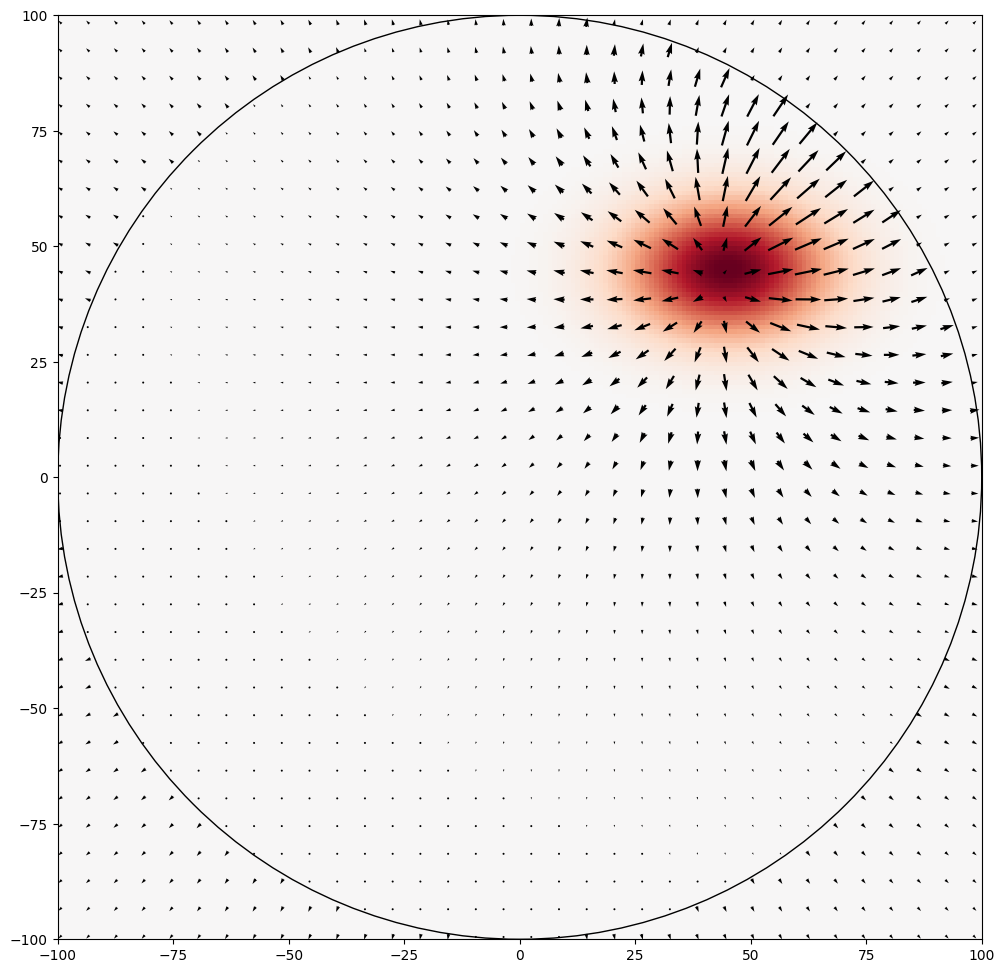

In [107]:
from beam_pipe import beam_pipe_gaussian_field

# Set up grid
pipe_radius = 100
grid_length = 200
x_list = np.arange(grid_length) + 0.5 - grid_length/2
y_list = np.arange(grid_length) + 0.5 - grid_length/2
x, y = np.meshgrid(x_list, y_list, indexing='ij')

# Choose Gaussian parameters
beam_pos_x = 45
beam_pos_y = 45
sigma_x = 10
sigma_y = 15

field_x, field_y = beam_pipe_gaussian_field(x, y, beam_pos_x, beam_pos_y, 
                                            sigma_x, sigma_y, pipe_radius) # Evaluate field
rho = (1/(2*np.pi*sigma_x*sigma_y)
       *np.exp(-(((x-beam_pos_x)/sigma_x)**2 + ((y-beam_pos_y)/sigma_y)**2) /2)) # Charge distribution

plot(rho, x, y, field_x, field_y)
ring = plt.Circle((0, 0), pipe_radius, fill=False) # Pipe
plt.gca().add_patch(ring) # Plot pipe

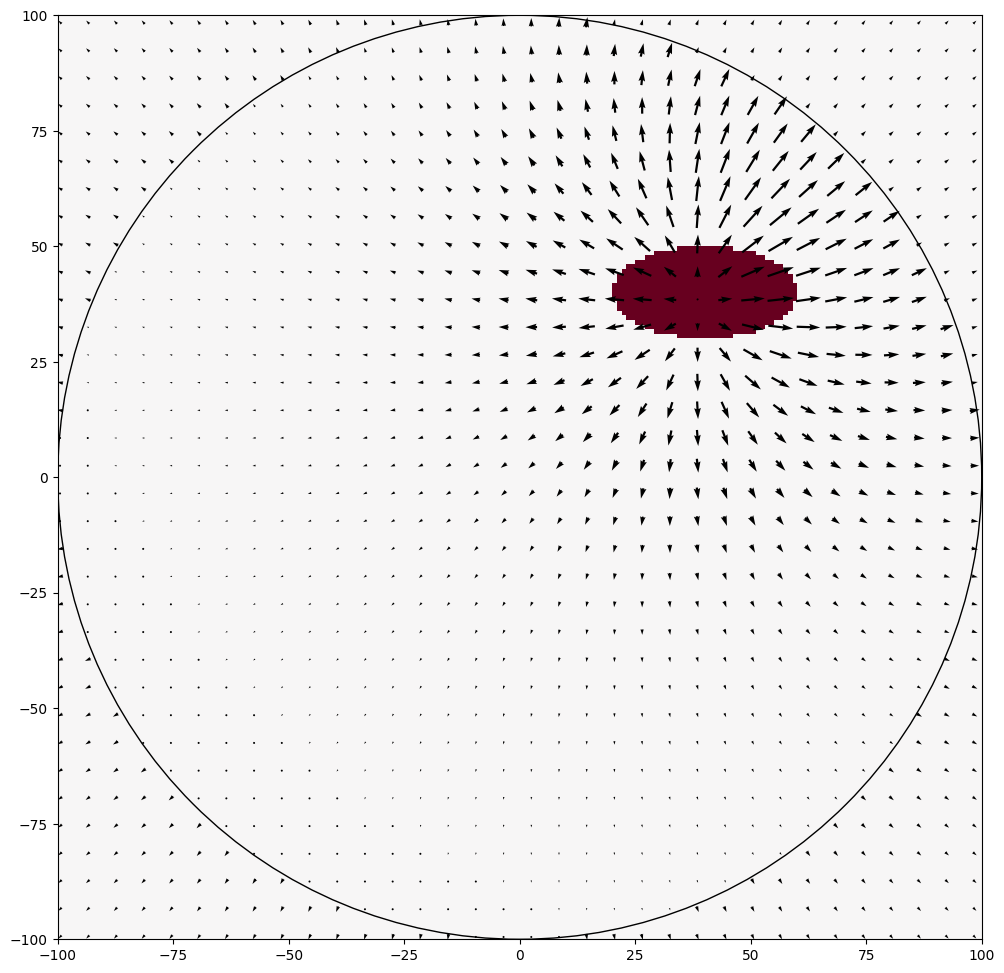

In [106]:
from beam_pipe import beam_pipe_uniform_field

# Set up grid
pipe_radius = 100
grid_length = 200
x_list = np.arange(grid_length) + 0.5 - grid_length/2
y_list = np.arange(grid_length) + 0.5 - grid_length/2
x, y = np.meshgrid(x_list, y_list, indexing='ij')

# Choose Gaussian parameters
beam_pos_x = 40
beam_pos_y = 40
a = 10
b = 20

field_x, field_y = beam_pipe_gaussian_field(x, y, beam_pos_x, beam_pos_y, 
                                            sigma_x, sigma_y, pipe_radius) # Evaluate field
rho = 1/(2*np.pi*a*b)*np.heaviside(1-(((x-beam_pos_x)/a)**2+((y-beam_pos_y)/b)**2), 1)
plot(rho, x, y, field_x, field_y)
ring = plt.Circle((0, 0), pipe_radius, fill=False) # Pipe
plt.gca().add_patch(ring) # Plot pipe